In [ ]:
# This part is for matplotlib configuration
import matplotlib as mpl

%config InlineBackend.figure_formats = ['svg']

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({'mathtext.fontset': 'cm'})
mpl.rcParams.update({'axes.labelsize': 22})
mpl.rcParams.update({'axes.titlesize': 16})
mpl.rcParams.update({'axes.linewidth': 0.5})
mpl.rcParams.update({'xtick.labelsize': 10})
mpl.rcParams.update({'ytick.labelsize': 10})

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys
import time
from scipy.optimize import curve_fit
import sys
from sklearn.metrics import r2_score



um:  [1.07220752]
ks:  [92.7195459]
R:  [[9.60076369e-06]
 [8.43870541e-06]
 [1.10394871e-04]
 [2.42876641e-04]
 [5.63757350e-04]
 [1.46423190e-05]
 [3.15181758e-04]
 [1.53570550e-04]
 [5.34050150e-05]
 [6.63707985e-07]
 [5.47844210e-04]
 [3.37781875e-04]
 [2.82739150e-06]
 [9.42578180e-06]
 [1.57246740e-04]]
 RMSE =  0.01298115988398007
0.9973844031439568


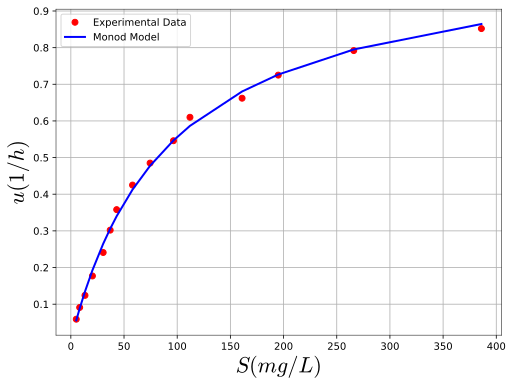

In [ ]:
# Monod Model
# generate the function

def monodmodel(S1, ks1, um1):
    return (um1 * S1)/(ks1 + S1)


f1 = monodmodel




# Data set
# S data (1/h)
S1 = np.array([5.1,8.3,13.3,20.3,30.4,37,43.1,58,74.5,96.5,112,161,195,266,386])

# u data (mg/L)
u1 = np.array([0.059,0.091,0.124,0.177,0.241,0.302,0.358,0.425,0.485,0.546,0.61,0.662,0.725,0.792,0.852])

u1 = np.reshape(u1, (15,1))

ks1 = 58.

def residual(actual, model):
    r = (actual-model)**2
    return r



def Jacobian1(f, residual, S1, ks1, um1):
    eps = 1e-6

    umplus = np.reshape(f(S1, ks1, um1 + eps), (15,1))
    residual_umplus = residual(u1, umplus)

    ummin = np.reshape(f(S1, ks1, um1 - eps), (15,1))
    residual_ummin = residual(u1, ummin)

    ksplus = np.reshape(f(S1, ks1 + eps, um1), (15,1))
    residual_ksplus = residual(u1, ksplus)

    ksmin = np.reshape(f(S1, ks1 - eps, um1), (15,1))
    residual_ksmin = residual(u1, ksmin)

    J_left = (residual_umplus - residual_ummin)/(2*eps)
    J_right = (residual_ksplus - residual_ksmin)/(2*eps)


    J = np.column_stack((J_left,J_right))

    return J

def Gauss_Newton1(f, Jacobian1, residual, S1, u1, u01, ks01, tol, max_iter):

    new1 = np.reshape(np.array([u01,ks01]), (2,1))

    for itr in range(max_iter):

        old1 = new1


        J = Jacobian1(f, residual,S1, old1[1,0], old1[0,0])


        current = np.reshape(f(S1, old1[1,0], old1[0,0]),(15,1))

        R = residual(u1, current)


        try:
            step1 = np.linalg.inv(np.dot(J.T,J))
        except:
            step1 = np.linalg.inv(np.dot(J.T,J)+1e-20)

        step2 = np.dot(step1, J.T)
        step3 = np.dot(step2, R)

        new1 = old1 - step3


    return new1, R


(compute, R) = Gauss_Newton1(f1, Jacobian1, residual, S1, u1, 0.189, 58, 1e-20, 10000)
print('um: ', compute[0])
print('ks: ',compute[1])
print('R: ', R)


RMSE = np.sqrt((np.sum(R))/15)
print(" RMSE = ", RMSE)

v_f1 = np.vectorize(monodmodel)

predicted1 = v_f1(S1,compute[1],compute[0] )


predicted1 = np.reshape(predicted1, (15,1))

SR = np.sum((u1-predicted1)**2)
ubar = np.mean(u1)
ST = np.sum((u1-ubar)**2)

r2 = 1 - SR/ST

print(r2)

# Plot the data
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot( S1, u1, 'o', color='red', linewidth = 2, label='Experimental Data')
ax.plot( S1, predicted1, '-', color='blue', linewidth = 2,  label='Monod Model')
ax.set_xlabel('$S(mg/L)$')
ax.set_ylabel('$u(1/h)$')
ax.legend()
ax.grid()




um:  [0.98498997]
ks:  [117.65778509]
n:  [1.09731232]
R:  [[1.29679119e-04]
 [1.54638350e-04]
 [1.09198197e-06]
 [6.41310507e-05]
 [3.93785337e-04]
 [4.92633338e-06]
 [3.06062745e-04]
 [7.68522883e-05]
 [3.01050975e-06]
 [4.72500359e-05]
 [3.22605895e-04]
 [3.73398297e-04]
 [1.89506521e-06]
 [6.94782038e-05]
 [1.13590671e-04]]
 RMSE =  0.01172574342473839
0.9978658517722231


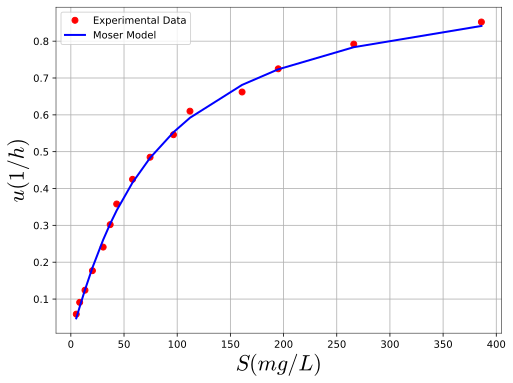

In [ ]:
# Moser Model
# generate the function

def mosermodel(S2, ks2, n, um2):
    return (um2 * (S2)**n)/(ks2 + (S2)**n)


f2 = mosermodel




# Data set
# S data (1/h)
S2 = np.array([5.1,8.3,13.3,20.3,30.4,37,43.1,58,74.5,96.5,112,161,195,266,386])

# u data (mg/L)
u2 = np.array([0.059,0.091,0.124,0.177,0.241,0.302,0.358,0.425,0.485,0.546,0.61,0.662,0.725,0.792,0.852])

u2 = np.reshape(u1, (15,1))

ks2 = 58.

def residual(actual, model):
    r = (actual-model)**2
    return r



def Jacobian2(f, residual, S2, ks2, n, um2):
    eps = 1e-6

    umplus = np.reshape(f(S2, ks2, n, um2 + eps), (15,1))
    residual_umplus = residual(u2, umplus)

    ummin = np.reshape(f(S2, ks2, n, um2 - eps), (15,1))
    residual_ummin = residual(u2, ummin)

    ksplus = np.reshape(f(S2, ks2 + eps, n, um2), (15,1))
    residual_ksplus = residual(u2, ksplus)

    ksmin = np.reshape(f(S2, ks2 - eps, n, um2), (15,1))
    residual_ksmin = residual(u2, ksmin)

    nplus = np.reshape(f(S2, ks2, n + eps, um2), (15,1))
    residual_nplus = residual(u2, nplus)

    nmin = np.reshape(f(S2, ks2, n - eps, um2), (15,1))
    residual_nmin = residual(u2, nmin)

    J_left = (residual_umplus - residual_ummin)/(2*eps)
    J_right = (residual_ksplus - residual_ksmin)/(2*eps)
    J_n = (residual_nplus - residual_nmin)/(2*eps)


    J = np.column_stack((J_left,J_right,J_n))

    return J

def Gauss_Newton2(f, Jacobian2, residual, S2, u2, u02, ks02, n, tol, max_iter):

    new2 = np.reshape(np.array([u02,ks02,n]), (3,1))

    for itr in range(max_iter):

        old2 = new2


        J = Jacobian2(f, residual,S2, old2[1,0], old2[2,0], old2[0,0])


        current = np.reshape(f(S2, old2[1,0], old2[2,0], old2[0,0]),(15,1))

        R = residual(u2, current)


        try:
            step1 = np.linalg.inv(np.dot(J.T,J))
        except:
            step1 = np.linalg.inv(np.dot(J.T,J)+1e-20)

        step2 = np.dot(step1, J.T)
        step3 = np.dot(step2, R)

        new2 = old2 - step3


    return new2, R


(compute, R) = Gauss_Newton2(f2, Jacobian2, residual, S2, u2, 0.189, 58,0.897, 1e-20, 10000) #u,k,n
print('um: ', compute[0])
print('ks: ',compute[1])
print('n: ',compute[2])
print('R: ', R)


RMSE = np.sqrt((np.sum(R))/15)
print(" RMSE = ", RMSE)

v_f2 = np.vectorize(mosermodel)

predicted2 = v_f2(S2,compute[1],compute[2],compute[0] )


predicted2 = np.reshape(predicted2, (15,1))

SR1 = np.sum((u2-predicted2)**2)
ubar1 = np.mean(u2)
ST1 = np.sum((u2-ubar1)**2)

r2_1 = 1 - SR1/ST1

print(r2_1)

# Plot the data
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot( S2, u2, 'o', color='red', linewidth = 2, label='Experimental Data')
ax.plot( S2, predicted2, '-', color='blue', linewidth = 2,  label='Moser Model')
ax.set_xlabel('$S(mg/L)$')
ax.set_ylabel('$u(1/h)$')
ax.legend()
ax.grid()




um:  [1.05410057]
ks:  [86.43391091]
m:  [0.0144873]
R:  [[1.94566951e-04]
 [1.40759916e-04]
 [1.61127678e-05]
 [1.38067403e-04]
 [5.08844754e-04]
 [1.46524272e-05]
 [2.86779163e-04]
 [1.07679545e-04]
 [2.31693377e-05]
 [1.02822896e-05]
 [4.56048772e-04]
 [3.54198950e-04]
 [8.39309000e-07]
 [9.56690927e-10]
 [4.35284656e-05]]
 RMSE =  0.012370747769660927
0.9976246057145047


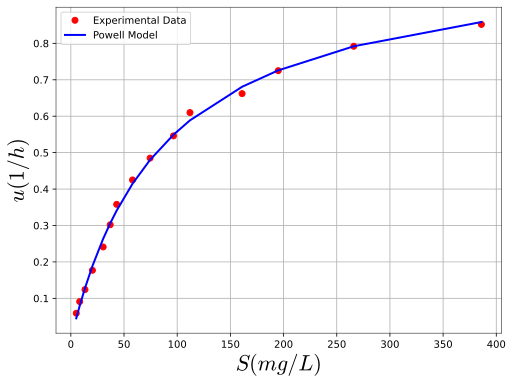

In [ ]:
# Powell model

# generate the function

def powellmodel(S3, ks3, m, um3):
     return (((um3 + m) * S3)/(ks3 + S3)) - m



f3 = powellmodel




# Data set
# S data (1/h)
S3 = np.array([5.1,8.3,13.3,20.3,30.4,37,43.1,58,74.5,96.5,112,161,195,266,386])

# u data (mg/L)
u3 = np.array([0.059,0.091,0.124,0.177,0.241,0.302,0.358,0.425,0.485,0.546,0.61,0.662,0.725,0.792,0.852])

u3 = np.reshape(u1, (15,1))

ks3 = 58.

def residual(actual, model):
    r = (actual-model)**2
    return r



def Jacobian3(f, residual, S3, ks3, m, um3):
    eps = 1e-6

    umplus = np.reshape(f(S3, ks3, m, um3 + eps), (15,1))
    residual_umplus = residual(u3, umplus)

    ummin = np.reshape(f(S3, ks3, m, um3 - eps), (15,1))
    residual_ummin = residual(u3, ummin)

    ksplus = np.reshape(f(S3, ks3 + eps, m, um3), (15,1))
    residual_ksplus = residual(u3, ksplus)

    ksmin = np.reshape(f(S3, ks3 - eps, m, um3), (15,1))
    residual_ksmin = residual(u3, ksmin)

    mplus = np.reshape(f(S3, ks3, m + eps, um3), (15,1))
    residual_mplus = residual(u3, mplus)

    mmin = np.reshape(f(S3, ks3, m - eps, um3), (15,1))
    residual_mmin = residual(u3, mmin)

    J_left = (residual_umplus - residual_ummin)/(2*eps)
    J_right = (residual_ksplus - residual_ksmin)/(2*eps)
    J_m = (residual_mplus - residual_mmin)/(2*eps)


    J = np.column_stack((J_left,J_right,J_m))

    return J

def Gauss_Newton3(f, Jacobian3, residual, S3, u3, u03, ks03, m, tol, max_iter):

    new3 = np.reshape(np.array([u03,ks03,m]), (3,1))

    for itr in range(max_iter):

        old3 = new3


        J = Jacobian3(f, residual,S3, old3[1,0], old3[2,0], old3[0,0])


        current = np.reshape(f(S3, old3[1,0], old3[2,0], old3[0,0]),(15,1))

        R = residual(u3, current)


        try:
            step1 = np.linalg.inv(np.dot(J.T,J))
        except:
            step1 = np.linalg.inv(np.dot(J.T,J)+1e-20)

        step2 = np.dot(step1, J.T)
        step3 = np.dot(step2, R)

        new3 = old3 - step3


    return new3, R


(compute, R) = Gauss_Newton3(f3, Jacobian3, residual, S3, u3, 0.189, 58,0.897, 1e-20, 10000)
print('um: ', compute[0])
print('ks: ',compute[1])
print('m: ',compute[2])
print('R: ', R)


RMSE = np.sqrt((np.sum(R))/15)
print(" RMSE = ", RMSE)

v_f2 = np.vectorize(powellmodel)

predicted3 = v_f2(S3,compute[1],compute[2],compute[0] )


predicted3 = np.reshape(predicted3, (15,1))

SR2 = np.sum((u3-predicted3)**2)
ubar2 = np.mean(u3)
ST2 = np.sum((u3-ubar2)**2)

r2_2 = 1 - SR2/ST2

print(r2_2)

# Plot
# Plot the data
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot( S3, u3, 'o', color='red', linewidth = 2, label='Experimental Data')
ax.plot( S3, predicted3, '-', color='blue', linewidth = 2,  label='Powell Model')
ax.set_xlabel('$S(mg/L)$')
ax.set_ylabel('$u(1/h)$')
ax.legend()
ax.grid()


um4:  [0.75716597]
ks4:  [122.49874915]
[[0.00075498]
 [0.0015759 ]
 [0.00174662]
 [0.00265488]
 [0.00281932]
 [0.00537328]
 [0.00839028]
 [0.00442244]
 [0.00060097]
 [0.00254696]
 [0.00676886]
 [0.00905656]
 [0.00103465]
 [0.00121341]
 [0.00899349]]
 RMSE =  0.062157118039690575
0.9400311742677965


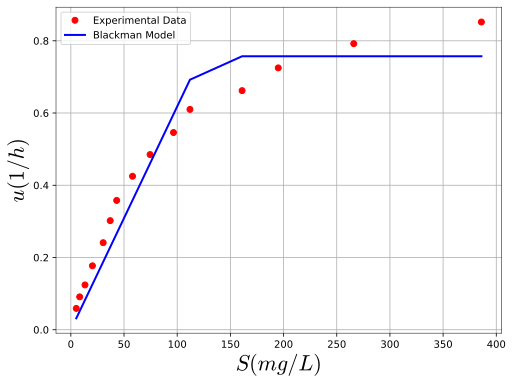

In [ ]:
# Blackman model
# generate the function
def blackmanmodel(um4, ks4, S4):
    if ks4 > S4:
        return ((um4 * S4)/ks4)
    elif ks4 <= S4:
        return um4

# Vectorize the function
v_f = np.vectorize(blackmanmodel)


# Data set
# S data (1/h)
S4 = np.array([5.1,8.3,13.3,20.3,30.4,37,43.1,58,74.5,96.5,112,161,195,266,386])

# u data (mg/L)
u4 = np.array([0.059,0.091,0.124,0.177,0.241,0.302,0.358,0.425,0.485,0.546,0.61,0.662,0.725,0.792,0.852])

u4 = np.reshape(u3, (15,1))

ks4 = 58.

def residual(actual, model):
    r = (actual-model)**2
    return r

def Jacobian4(v_f, residual, um4, ks4, S4):
    eps = 1e-6

    umplus = np.reshape(v_f(um4 + eps, ks4, S4), (15,1))
    residual_umplus = residual(u4, umplus)

    ummin = np.reshape(v_f(um4 - eps, ks4, S4), (15,1))
    residual_ummin = residual(u4, ummin)

    ksplus = np.reshape(v_f(um4, ks4 + eps, S4), (15,1))
    residual_ksplus = residual(u4, ksplus)

    ksmin = np.reshape(v_f(um4, ks4 - eps, S4), (15,1))
    residual_ksmin = residual(u4, ksmin)

    J_left = (residual_umplus - residual_ummin)/(2*eps)
    J_right = (residual_ksplus - residual_ksmin)/(2*eps)


    J = np.column_stack((J_left,J_right))

    return J


def Gauss_Newton4(v_f, Jacobian4, residual, S4, u4, u04, ks04, tol, max_iter):

    new4 = np.reshape(np.array([u04,ks04]), (2,1))

    for itr in range(max_iter):

        old4 = new4

        J = Jacobian4(v_f, residual, old4[0,0], old4[1,0], S4)

        current = np.reshape(v_f(old4[0,0], old4[1,0], S4),(15,1))

        R = residual(u4, current)


        try:
            step1 = np.linalg.inv(np.dot(J.T,J))
        except:
            step1 = np.linalg.inv(np.dot(J.T,J)+1e-20)

        step2 = np.dot(step1, J.T)
        step3 = np.dot(step2, R)


        new4 = old4 - step3

    return new4,R

(compute,R) = Gauss_Newton4(v_f, Jacobian4, residual, S4, u4, 0.189, 58, 1e-20, 10000)
print('um4: ', compute[0])
print('ks4: ',compute[1])
print(R)

RMSE = np.sqrt((np.sum(R))/15)
print(" RMSE = ", RMSE)



predicted4 = v_f(compute[0], compute[1], S4)



predicted4 = np.reshape(predicted4, (15,1))

SR = np.sum((u4-predicted4)**2)
ubar = np.mean(u4)
ST = np.sum((u4-ubar)**2)

r2 = 1 - SR/ST

print(r2)

# Plot the data
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot( S4, u4, 'o', color='red', linewidth = 2, label='Experimental Data')
ax.plot( S4, predicted4, '-', color='blue', linewidth = 2,  label='Blackman Model')
ax.set_xlabel('$S(mg/L)$')
ax.set_ylabel('$u(1/h)$')
ax.legend()
ax.grid()



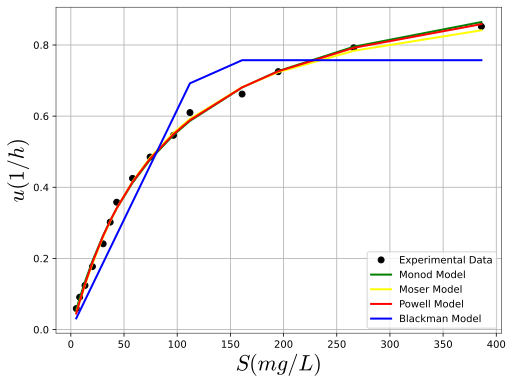

In [ ]:
# Plot the data
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot( S4, u4, 'o', color='black', linewidth = 2, label='Experimental Data')
ax.plot( S1, predicted1, '-', color='green', linewidth = 2,  label='Monod Model')
ax.plot( S2, predicted2, '-', color='yellow', linewidth = 2,  label='Moser Model')
ax.plot( S3, predicted3, '-', color='red', linewidth = 2,  label='Powell Model')
ax.plot( S4, predicted4, '-', color='blue', linewidth = 2,  label='Blackman Model')
ax.set_xlabel('$S(mg/L)$')
ax.set_ylabel('$u(1/h)$')
ax.legend()
ax.grid()